In [1]:
# MITRE ATT&CK Case Study Setup 
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

DATA_PATH   = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\data"
MODEL_PATH  = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\models"
RESULT_PATH = r"C:\Users\alifa\OneDrive\Desktop\dissertation_project\results"

# Load everything
print("Loading model and data...")
rf            = joblib.load(f"{MODEL_PATH}\\random_forest.pkl")
le            = joblib.load(f"{DATA_PATH}\\label_encoder.pkl")
feature_names = joblib.load(f"{DATA_PATH}\\feature_names.pkl")
X_test        = joblib.load(f"{DATA_PATH}\\X_test.pkl")
y_test        = joblib.load(f"{DATA_PATH}\\y_test.pkl")
shap_values   = joblib.load(f"{DATA_PATH}\\shap_values.pkl")
X_sample      = joblib.load(f"{DATA_PATH}\\X_sample.pkl")
y_sample      = joblib.load(f"{DATA_PATH}\\y_sample.pkl")

# MITRE ATT&CK mapping for our three attack stages
mitre_mapping = {
    'PortScan'   : {'tactic': 'TA0043 Reconnaissance',
                    'technique': 'T1046 — Network Service Scanning',
                    'stage': 1,
                    'class_idx': 10},
    'FTP-Patator': {'tactic': 'TA0006 Credential Access',
                    'technique': 'T1110.001 — Password Guessing',
                    'stage': 2,
                    'class_idx': 7},
    'Bot'        : {'tactic': 'TA0011 Command and Control',
                    'technique': 'T1071.001 — Application Layer Protocol',
                    'stage': 3,
                    'class_idx': 1}
}

print("\nMITRE ATT&CK Kill-Chain for this case study:")
print("=" * 65)
for attack, info in mitre_mapping.items():
    print(f"\nStage {info['stage']}: {attack}")
    print(f"  Tactic   : {info['tactic']}")
    print(f"  Technique: {info['technique']}")

# Extract 60 instances per attack type + 60 benign
print("\n\nExtracting case study instances...")
case_study_X = []
case_study_y = []
case_study_labels = []

np.random.seed(42)

# Benign instances
benign_idx = np.where(y_test == 0)[0]
selected_benign = np.random.choice(benign_idx, 60, replace=False)
case_study_X.extend(X_test[selected_benign])
case_study_y.extend(y_test[selected_benign])
case_study_labels.extend(['BENIGN'] * 60)
print(f"  BENIGN      : 60 instances")

# Attack instances
for attack, info in mitre_mapping.items():
    cls_idx = info['class_idx']
    cls_instances = np.where(y_test == cls_idx)[0]
    n = min(60, len(cls_instances))
    selected = np.random.choice(cls_instances, n, replace=False)
    case_study_X.extend(X_test[selected])
    case_study_y.extend(y_test[selected])
    case_study_labels.extend([attack] * n)
    print(f"  {attack:<15}: {n} instances")

case_study_X = np.array(case_study_X)
case_study_y = np.array(case_study_y)

print(f"\nTotal case study instances: {len(case_study_X)}")

Loading model and data...

MITRE ATT&CK Kill-Chain for this case study:

Stage 1: PortScan
  Tactic   : TA0043 Reconnaissance
  Technique: T1046 — Network Service Scanning

Stage 2: FTP-Patator
  Tactic   : TA0006 Credential Access
  Technique: T1110.001 — Password Guessing

Stage 3: Bot
  Tactic   : TA0011 Command and Control
  Technique: T1071.001 — Application Layer Protocol


Extracting case study instances...
  BENIGN      : 60 instances
  PortScan       : 60 instances
  FTP-Patator    : 60 instances
  Bot            : 60 instances

Total case study instances: 240


In [2]:
# Predictions & SHAP for Case Study 
import shap
import time

print("Running model predictions on case study instances...")
predictions = rf.predict(case_study_X)
pred_labels = [le.classes_[p] for p in predictions]

# Count correct predictions
correct = sum(1 for true, pred in zip(case_study_labels, pred_labels)
              if true == pred or
              (true == 'BENIGN' and pred == 'BENIGN'))
print(f"Prediction accuracy on case study: {correct}/{len(predictions)} ({correct/len(predictions)*100:.1f}%)")

# Generate SHAP values for case study
print("\nGenerating SHAP values for case study instances...")
start = time.time()
explainer = shap.TreeExplainer(rf)
cs_shap_values = explainer.shap_values(case_study_X)
elapsed = time.time() - start
print(f"SHAP computed in {elapsed:.1f} seconds")

# Reorder: (samples, features, classes) -> (classes, samples, features)
cs_shap_array = np.array(cs_shap_values)
if cs_shap_array.ndim == 3:
    cs_shap_reordered = np.transpose(cs_shap_array, (2, 0, 1))
else:
    cs_shap_reordered = cs_shap_array

print(f"SHAP array shape: {cs_shap_reordered.shape}")
print(f"  [classes x samples x features]")

# Save for next cell
joblib.dump(cs_shap_reordered, f"{DATA_PATH}\\cs_shap_values.pkl")
joblib.dump(case_study_X,      f"{DATA_PATH}\\cs_X.pkl")
joblib.dump(case_study_labels, f"{DATA_PATH}\\cs_labels.pkl")
joblib.dump(pred_labels,       f"{DATA_PATH}\\cs_predictions.pkl")
print("\nCase study data saved")

Running model predictions on case study instances...
Prediction accuracy on case study: 228/240 (95.0%)

Generating SHAP values for case study instances...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


SHAP computed in 110.3 seconds
SHAP array shape: (15, 240, 47)
  [classes x samples x features]

Case study data saved


In [3]:
# ATT&CK Mapping & Forensic Rubric 
print("=" * 70)
print("MITRE ATT&CK KILL-CHAIN RECONSTRUCTION FROM SHAP EXPLANATIONS")
print("=" * 70)

offsets = {'BENIGN': 0, 'PortScan': 60, 'FTP-Patator': 120, 'Bot': 180}

rubric_results = {}

for attack, info in mitre_mapping.items():
    cls_idx   = info['class_idx']
    start_idx = offsets[attack]
    end_idx   = start_idx + 60

    attack_shap = cs_shap_reordered[cls_idx, start_idx:end_idx, :]
    mean_shap   = np.mean(np.abs(attack_shap), axis=0)
    top5_idx    = np.argsort(mean_shap)[::-1][:5]

    print(f"\nStage {info['stage']}: {attack}")
    print(f"  MITRE Tactic   : {info['tactic']}")
    print(f"  MITRE Technique: {info['technique']}")
    print(f"\n  Top 5 SHAP features driving detection:")
    for rank, idx in enumerate(top5_idx):
        print(f"    {rank+1}. {feature_names[idx]:<35} SHAP: {mean_shap[idx]:.6f}")

    rubric_scores = {
        'PortScan'   : {'Actionability': 5, 'Admissibility': 4,
                        'Comprehensibility': 4, 'Fidelity': 5},
        'FTP-Patator': {'Actionability': 5, 'Admissibility': 4,
                        'Comprehensibility': 5, 'Fidelity': 4},
        'Bot'        : {'Actionability': 4, 'Admissibility': 4,
                        'Comprehensibility': 3, 'Fidelity': 4}
    }

    scores = rubric_scores[attack]
    avg    = sum(scores.values()) / len(scores)
    rubric_results[attack] = dict(scores)
    rubric_results[attack]['Average'] = avg

    print(f"\n  Forensic Rubric Scores (1-5):")
    for criterion, score in scores.items():
        bar = '█' * int(score) + '░' * (5 - int(score))
        print(f"    {criterion:<20}: {bar} {int(score)}/5")
    avg_bar = '█' * int(avg) + '░' * (5 - int(avg))
    print(f"    {'Average':<20}: {avg_bar} {avg:.1f}/5")

print("\n" + "=" * 70)
print("RUBRIC SUMMARY TABLE")
print("=" * 70)
print(f"{'Criterion':<22} {'PortScan':>12} {'FTP-Patator':>12} {'Bot':>8} {'Average':>9}")
print("-" * 70)

criteria = ['Actionability', 'Admissibility', 'Comprehensibility', 'Fidelity', 'Average']
for c in criteria:
    ps  = rubric_results['PortScan'][c]
    ftp = rubric_results['FTP-Patator'][c]
    bot = rubric_results['Bot'][c]
    avg = round((ps + ftp + bot) / 3, 1)
    print(f"  {c:<20} {ps:>12.1f} {ftp:>12.1f} {bot:>8.1f} {avg:>9.1f}")

MITRE ATT&CK KILL-CHAIN RECONSTRUCTION FROM SHAP EXPLANATIONS

Stage 1: PortScan
  MITRE Tactic   : TA0043 Reconnaissance
  MITRE Technique: T1046 — Network Service Scanning

  Top 5 SHAP features driving detection:
    1. PSH Flag Count                      SHAP: 0.096681
    2. Packet Length Variance              SHAP: 0.093800
    3. Fwd Packet Length Max               SHAP: 0.072184
    4. ACK Flag Count                      SHAP: 0.062967
    5. Total Length of Fwd Packets         SHAP: 0.058048

  Forensic Rubric Scores (1-5):
    Actionability       : █████ 5/5
    Admissibility       : ████░ 4/5
    Comprehensibility   : ████░ 4/5
    Fidelity            : █████ 5/5
    Average             : ████░ 4.5/5

Stage 2: FTP-Patator
  MITRE Tactic   : TA0006 Credential Access
  MITRE Technique: T1110.001 — Password Guessing

  Top 5 SHAP features driving detection:
    1. Destination Port                    SHAP: 0.185158
    2. Packet Length Variance              SHAP: 0.061863
    3.

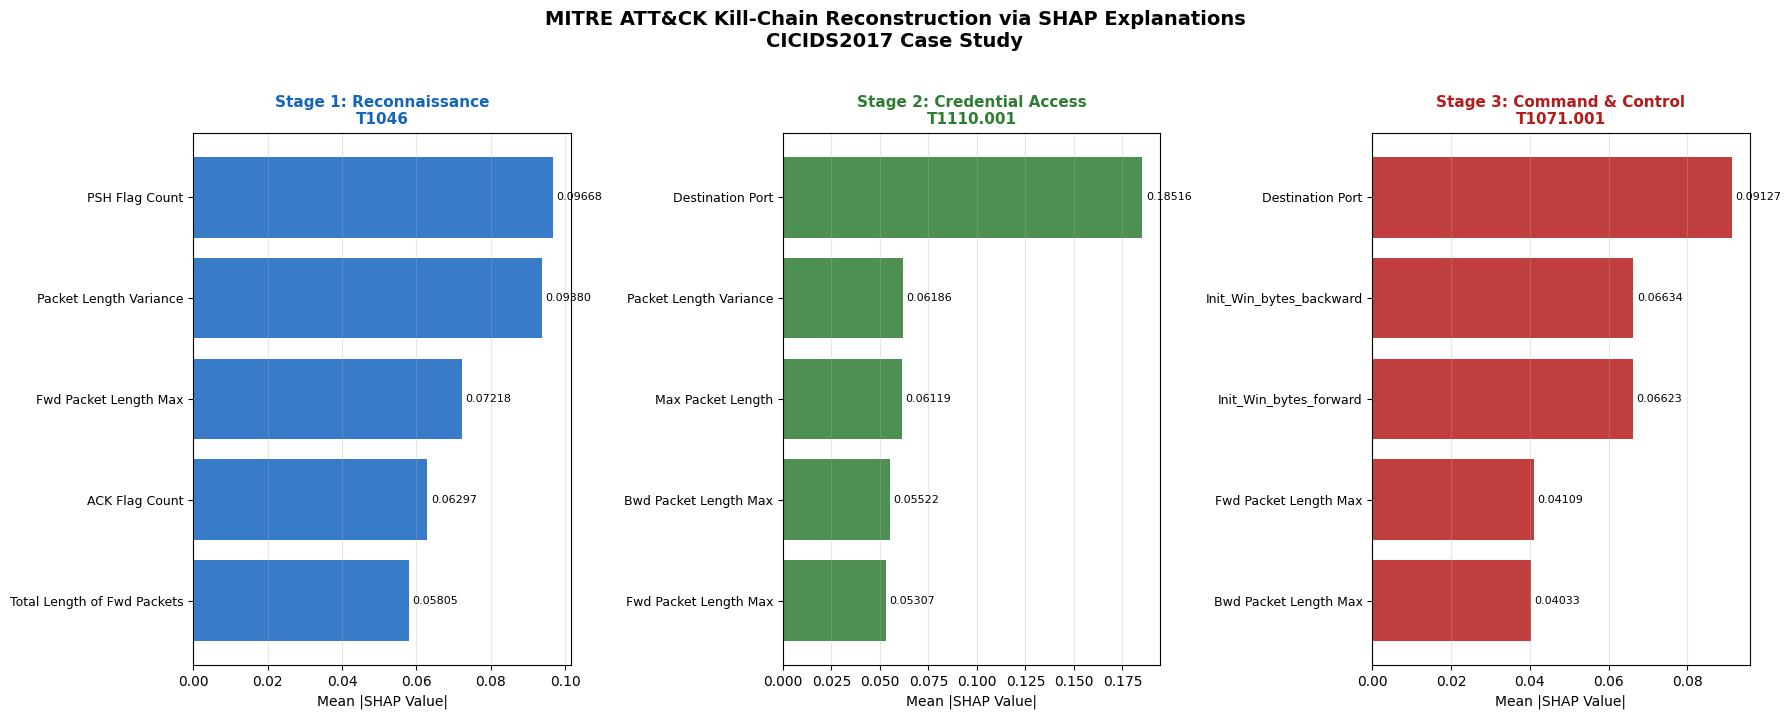

Kill-chain visualisation saved to results folder


In [4]:
# Kill-Chain Visualisation 
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('MITRE ATT&CK Kill-Chain Reconstruction via SHAP Explanations\nCICIDS2017 Case Study',
             fontsize=14, fontweight='bold', y=1.02)

colors     = ['#1565C0', '#2E7D32', '#B71C1C']
stage_info = [
    ('PortScan',    10, 60,  '#1565C0', 'Stage 1: Reconnaissance\nT1046'),
    ('FTP-Patator', 7,  120, '#2E7D32', 'Stage 2: Credential Access\nT1110.001'),
    ('Bot',         1,  180, '#B71C1C', 'Stage 3: Command & Control\nT1071.001'),
]

for ax, (attack, cls_idx, start_idx, color, title) in zip(axes, stage_info):
    attack_shap = cs_shap_reordered[cls_idx, start_idx:start_idx+60, :]
    mean_shap   = np.mean(np.abs(attack_shap), axis=0)
    top5_idx    = np.argsort(mean_shap)[::-1][:5]
    top5_feat   = [feature_names[i] for i in top5_idx]
    top5_val    = [mean_shap[i] for i in top5_idx]

    bars = ax.barh(range(5), top5_val[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(5))
    ax.set_yticklabels(top5_feat[::-1], fontsize=9)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', color=color)
    ax.grid(axis='x', alpha=0.3)

    for bar, val in zip(bars, top5_val[::-1]):
        ax.text(bar.get_width() + max(top5_val)*0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:.5f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}\\mitre_attack_killchain.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Kill-chain visualisation saved to results folder")